# Notebook 4 - Ejecucion y Costes
Backtesting LONG-only realista de la estrategia Momentum de Notebook 3.

## Configuracion

In [44]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.fs as fs

sns.set(style="whitegrid", context="notebook")

START_DATE = pd.Timestamp("2015-01-01")
INITIAL_CAPITAL = 250000.0
TOP_N = 20
TARGET_W = 1.0 / TOP_N
FEE_RATE = 0.0023
MIN_FEE = 23.0
BENCH = "SPY"

# Control de rotacion: 1=mensual, 3=trimestral, 6=semestral
REBALANCE_EVERY_N_MONTHS = 6

PRICE_PATH_HINTS = [
    "data/processed/prices.parquet",
    "data/raw/sp500_history.parquet",
    "notebooks/data/processed/prices.parquet",
    "notebooks/data/raw/sp500_history.parquet",
    r"C:\Users\alons\Desktop\Pr?ctica 7\sp500_history.parquet",
    r"C:\Users\alons\Desktop\Practica 7\sp500_history.parquet",
]

SELECTION_PATH_HINTS = [
    "outputs/selected_top20_by_rebalance.csv",
    "outputs/selected_20_each_rebalance.csv",
    "notebooks/outputs/selected_top20_by_rebalance.csv",
    "notebooks/outputs/selected_20_each_rebalance.csv",
    "selected_top20_by_rebalance.csv",
]

# Parametros canonicos del FIX (backtest principal)
MAX_FEE_PCT = 0.01
# Evita quedar 100% en cash si el filtro de notional bloquea TODAS las compras de un rebalance.
ALLOW_MIN_NOTIONAL_RELAX_IF_BLOCKED = True
# Evita cash negativo cuando una venta forzosa muy pequena no cubre fee minimo.
CLIP_FORCED_EXIT_FEE_TO_AVAILABLE_CASH = True
MTM_FFILL_LIMIT = 1
MAX_POSITION_WEIGHT = 0.15
ENFORCE_WEIGHT_CAP_DAILY = True

# Control anti-outliers OPEN/CLOSE. Debe ser > 1.
MAX_OPEN_CLOSE_RATIO = 4.0
# Si True: aborta el backtest al detectar anomalia OPEN/CLOSE en salida (evita equity contaminada).
HARD_FAIL_ON_OPEN_CLOSE_ANOMALY = False
# Si True: ante anomalia OPEN/CLOSE en salida, no ejecuta ese exit (evita PnL ficticio).
SKIP_EXIT_ON_OPEN_CLOSE_ANOMALY = True


## Funciones base

In [45]:
def compute_commission(notional, rate=0.0023, min_fee=23.0):
    n = float(abs(notional))
    if n <= 0:
        return 0.0
    return max(rate * n, min_fee)


def make_rebalance_dates(index):
    idx = pd.DatetimeIndex(index).sort_values().unique()
    if len(idx) == 0:
        return pd.DatetimeIndex([])
    s = pd.Series(idx, index=idx)
    out = s.groupby(s.index.to_period("M")).max().sort_values()
    return pd.DatetimeIndex(out.values)


def get_month_end_dates(index):
    return make_rebalance_dates(index)


def compute_metrics(equity, benchmark=None, freq=252):
    eq = pd.Series(equity).dropna().sort_index()
    if len(eq) < 2:
        return {}
    r = eq.pct_change().dropna()
    yrs = len(r) / float(freq)
    cagr = (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1 if yrs > 0 else np.nan
    vol = r.std(ddof=0) * np.sqrt(freq)
    sharpe = (r.mean() / r.std(ddof=0) * np.sqrt(freq)) if r.std(ddof=0) > 0 else np.nan
    dd = eq / eq.cummax() - 1
    out = {
        "total_return": eq.iloc[-1] / eq.iloc[0] - 1,
        "cagr": cagr,
        "vol": vol,
        "sharpe": sharpe,
        "max_drawdown": dd.min(),
    }
    if benchmark is not None:
        b = pd.Series(benchmark).dropna().sort_index()
        a = pd.concat([eq, b], axis=1, join="inner").dropna()
        if len(a) > 2:
            rs = a.iloc[:, 0].pct_change().dropna()
            rb = a.iloc[:, 1].pct_change().dropna()
            x = pd.concat([rs, rb], axis=1).dropna()
            if len(x) > 2:
                out["alpha_daily_mean"] = (x.iloc[:, 0] - x.iloc[:, 1]).mean()
                vb = np.var(x.iloc[:, 1])
                out["beta"] = np.cov(x.iloc[:, 0], x.iloc[:, 1])[0, 1] / vb if vb > 0 else np.nan
    return out


def monte_carlo_monkeys(monthly_returns, n_monos=2000, chunk_size=6, fee_rate=0.0023):
    r = pd.Series(monthly_returns).dropna().astype(float)
    if len(r) < max(24, chunk_size * 2):
        raise ValueError("No hay suficientes retornos mensuales para Monte Carlo por bloques.")
    v = r.values
    n = len(v)
    starts = np.arange(n - chunk_size + 1)
    drag = fee_rate / 12.0
    rows = []
    for _ in range(int(n_monos)):
        path = []
        while len(path) < n:
            st = np.random.choice(starts)
            path.extend(v[st:st + chunk_size].tolist())
        path = np.array(path[:n]) - drag
        wealth = np.cumprod(1 + path)
        yrs = n / 12.0
        cagr = wealth[-1] ** (1 / yrs) - 1 if yrs > 0 and wealth[-1] > 0 else np.nan
        vol = np.std(path, ddof=0) * np.sqrt(12)
        sharpe = (np.mean(path) / np.std(path, ddof=0) * np.sqrt(12)) if np.std(path, ddof=0) > 0 else np.nan
        rows.append((wealth[-1] - 1, cagr, vol, sharpe))
    return pd.DataFrame(rows, columns=["total_return", "cagr", "vol", "sharpe"])


## Carga y adapter de precios (OPEN/CLOSE)

In [46]:
def _scan_files(roots):
    lfs = fs.LocalFileSystem()
    out, seen = [], set()
    for root in roots:
        try:
            info = lfs.get_file_info(root)
            if info.type == fs.FileType.File:
                if root not in seen:
                    out.append(root)
                    seen.add(root)
                continue
        except Exception:
            pass
        try:
            infos = lfs.get_file_info(fs.FileSelector(root, recursive=True))
        except Exception:
            continue
        for i in infos:
            if i.type != fs.FileType.File:
                continue
            p = i.path
            pl = p.lower()
            if pl.endswith('.parquet') or pl.endswith('.csv'):
                if 'selected_top20_by_rebalance' in pl:
                    continue
                if p not in seen:
                    out.append(p)
                    seen.add(p)
    return out


def _read_any(path):
    try:
        if path.lower().endswith('.parquet'):
            return pq.read_table(path).to_pandas()
        if path.lower().endswith('.csv'):
            return pd.read_csv(path)
    except Exception:
        return None
    return None


def _canon(c):
    return str(c).strip().lower().replace(' ', '_').replace('-', '_').replace('.', '_')


def _find_col(cols, candidates):
    cmap = {_canon(c): c for c in cols}
    for c in candidates:
        if c in cmap:
            return cmap[c]
    return None


def _extract_field(df, field):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None

    # MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        l0 = pd.Index([_canon(c) for c in df.columns.get_level_values(0)])
        l1 = pd.Index([_canon(c) for c in df.columns.get_level_values(1)])

        keys = [field]
        if field == 'close':
            keys = ['adj_close', 'adj close', 'close']
        if field == 'unadjusted_close':
            keys = ['unadjusted_close', 'unadjusted close']

        for key in keys:
            k = _canon(key)
            if k in l0.values:
                out = df.xs(k, axis=1, level=0)
                out.columns = [str(c).upper() for c in out.columns]
                return out.sort_index()
            if k in l1.values:
                out = df.xs(k, axis=1, level=1)
                out.columns = [str(c).upper() for c in out.columns]
                return out.sort_index()

    # Long format
    date_col = _find_col(df.columns, ['date', 'datetime', 'timestamp', 'fecha'])
    ticker_col = _find_col(df.columns, ['ticker', 'symbol', 'asset', 'activo'])
    field_col = _find_col(df.columns, [field, field.replace('_', ' ')])

    if field_col is None and field == 'close':
        field_col = _find_col(df.columns, ['adj_close', 'adj close', 'close'])

    if date_col is not None and ticker_col is not None and field_col is not None:
        x = df[[date_col, ticker_col, field_col]].copy()
        x[date_col] = pd.to_datetime(x[date_col], errors='coerce')
        x[ticker_col] = x[ticker_col].astype(str).str.upper()
        x = x.dropna(subset=[date_col, ticker_col, field_col])
        out = x.pivot_table(index=date_col, columns=ticker_col, values=field_col, aggfunc='last')
        return out.sort_index()

    # Flat wide columns
    x = df.copy()
    if not isinstance(x.index, pd.DatetimeIndex):
        dcol = _find_col(x.columns, ['date', 'datetime', 'timestamp', 'fecha'])
        if dcol is None:
            return None
        x[dcol] = pd.to_datetime(x[dcol], errors='coerce')
        x = x.dropna(subset=[dcol]).set_index(dcol)

    out = pd.DataFrame(index=x.index)
    for c in x.columns:
        n = _canon(c)
        parts = [p for p in n.split('_') if p]
        if len(parts) < 2:
            continue

        tk = None
        if field in ['open', 'high', 'low', 'close', 'adj_close']:
            if parts[-1] == field:
                tk = '_'.join(parts[:-1]).upper()
            elif parts[0] == field:
                tk = '_'.join(parts[1:]).upper()
            elif field in ['close', 'adj_close'] and parts[-2:] == ['adj', 'close']:
                tk = '_'.join(parts[:-2]).upper()
        elif field == 'unadjusted_close':
            if parts[-2:] == ['unadjusted', 'close']:
                tk = '_'.join(parts[:-2]).upper()

        if tk and len(tk) > 0:
            out[tk] = pd.to_numeric(x[c], errors='coerce')

    if out.shape[1] == 0:
        return None
    return out.sort_index()


def _align_panels(panels):
    all_idx = pd.DatetimeIndex(sorted(set().union(*[set(v.index) for v in panels.values() if v is not None])))
    all_cols = sorted(set().union(*[set(v.columns) for v in panels.values() if v is not None]))

    out = {}
    for k, v in panels.items():
        if v is None:
            out[k] = pd.DataFrame(index=all_idx, columns=all_cols, dtype=float)
        else:
            x = v.copy()
            x.index = pd.to_datetime(x.index, errors='coerce')
            x = x[~x.index.isna()].sort_index()
            x = x[~x.index.duplicated(keep='last')]
            x = x.replace([np.inf, -np.inf], np.nan)
            x.columns = [str(c).upper() for c in x.columns]
            out[k] = x.reindex(index=all_idx, columns=all_cols)
    return out


def _report_ratio_extremes(ratio_df, title):
    s = ratio_df.stack().replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) == 0:
        print(f'{title}: sin datos')
        return pd.DataFrame()
    print(title)
    print(s.quantile([0.01, 0.5, 0.99, 0.999]))

    ext = s.rename('ratio').to_frame()
    ext['abs_log'] = np.abs(np.log(ext['ratio'].replace(0, np.nan)))
    ext = ext.replace([np.inf, -np.inf], np.nan).dropna().sort_values('abs_log', ascending=False).head(20)
    print('Top 20 extremos:')
    display(ext)
    return ext


def _build_consistent_prices_from_raw(df):
    panels = {
        'open_raw': _extract_field(df, 'open'),
        'high_raw': _extract_field(df, 'high'),
        'low_raw': _extract_field(df, 'low'),
        'close_raw': _extract_field(df, 'close'),
        'adj_close': _extract_field(df, 'adj_close'),
        'unadjusted_close': _extract_field(df, 'unadjusted_close'),
    }
    panels = _align_panels(panels)

    open_raw = panels['open_raw']
    close_raw = panels['close_raw']
    adj_close = panels['adj_close']
    unadj_close = panels['unadjusted_close']

    # close usado
    has_adj = adj_close.notna().sum().sum() > 0
    close_used = adj_close.copy() if has_adj else close_raw.copy()

    factor = None
    factor_source = None
    mode = None

    if has_adj and open_raw.notna().sum().sum() > 0:
        if unadj_close.notna().sum().sum() > 0:
            factor = (adj_close / unadj_close).replace([np.inf, -np.inf], np.nan)
            factor_source = 'adj_close / unadjusted_close'
        elif close_raw.notna().sum().sum() > 0:
            factor = (adj_close / close_raw).replace([np.inf, -np.inf], np.nan)
            factor_source = 'adj_close / close_raw'

        if factor is not None:
            raw_factor = factor.copy()
            low_q = raw_factor.stack().quantile(0.001) if raw_factor.stack().notna().sum() > 0 else np.nan
            hi_q = raw_factor.stack().quantile(0.999) if raw_factor.stack().notna().sum() > 0 else np.nan
            print('Factor source:', factor_source, '| q0.1%:', low_q, 'q99.9%:', hi_q)

            clipped = factor.clip(lower=0.1, upper=10.0)
            clipped_outliers = ((factor < 0.1) | (factor > 10.0)).stack().fillna(False)
            n_clip = int(clipped_outliers.sum())
            if n_clip > 0:
                print(f'WARNING: factores fuera de [0.1,10] -> {n_clip} observaciones (clip aplicado).')

            open_used = open_raw * clipped
            mode = 'adjusted_consistent'
        else:
            open_used = open_raw.copy()
            close_used = close_raw.copy()
            mode = 'raw_consistent_fallback'
    else:
        # sin base fiable para ajustar open -> mantener todo en no ajustado
        open_used = open_raw.copy()
        if close_raw.notna().sum().sum() > 0:
            close_used = close_raw.copy()
            mode = 'raw_consistent'
        else:
            open_used = close_used.copy()
            mode = 'close_only_fallback'

    ratio = (open_used / close_used).replace([np.inf, -np.inf], np.nan)
    _report_ratio_extremes(ratio, 'Chequeo open_used / close_used')

    return {
        'open_used': open_used,
        'close_used': close_used,
        'open_raw': open_raw,
        'close_raw': close_raw,
        'adj_close': adj_close,
        'unadjusted_close': unadj_close,
        'scale_mode': mode,
        'factor_source': factor_source,
    }


def load_prices():
    dynamic_paths = []
    if 'PARQUET_PATH' in globals() and isinstance(globals()['PARQUET_PATH'], str):
        dynamic_paths.append(globals()['PARQUET_PATH'])

    # fallback robusto: buscar por nombre en Desktop
    try:
        infos = fs.LocalFileSystem().get_file_info(fs.FileSelector(r'C:\Users\alons\Desktop', recursive=True))
        for info in infos:
            if info.type == fs.FileType.File and info.path.lower().endswith('sp500_history.parquet'):
                dynamic_paths.append(info.path)
    except Exception:
        pass

    paths = dynamic_paths + PRICE_PATH_HINTS + _scan_files(['data', 'notebooks/data'])

    seen, ordered = set(), []
    for p in paths:
        if p not in seen:
            ordered.append(p)
            seen.add(p)

    best = (None, None, None, None, -1)
    for p in ordered:
        raw = _read_any(p)
        if raw is None or not isinstance(raw, pd.DataFrame) or raw.empty:
            continue

        built = _build_consistent_prices_from_raw(raw)
        op = built['open_used']
        cl = built['close_used']

        score = cl.shape[0] * max(1, cl.shape[1])
        if cl.shape[1] >= TOP_N and cl.shape[0] >= 260:
            print('Fuente precios:', p)
            print('Scale mode:', built['scale_mode'])
            return op, cl, built, p

        if score > best[4]:
            best = (op, cl, built, p, score)

    if best[0] is not None:
        print('Fuente precios (mejor disponible):', best[3])
        print('Scale mode:', best[2]['scale_mode'])
        return best[0], best[1], best[2], best[3]

    raise FileNotFoundError('No se pudo leer una fuente de precios valida. Ejecuta Notebook 1 o define PARQUET_PATH a sp500_history.parquet.')


open_px, close_px, price_panels, price_source = load_prices()

# FIX canonico: unificar escala OPEN/HIGH/LOW a CLOSE de forma incondicional.
close_bt = close_px.copy()
open_bt = open_px.copy()

open_raw_panel = price_panels.get('open_raw') if isinstance(price_panels, dict) else None
unadj_panel = price_panels.get('unadjusted_close') if isinstance(price_panels, dict) else None
close_raw_panel = price_panels.get('close_raw') if isinstance(price_panels, dict) else None

if isinstance(open_raw_panel, pd.DataFrame) and open_raw_panel.notna().sum().sum() > 0:
    open_raw_aligned = open_raw_panel.reindex(index=close_bt.index, columns=close_bt.columns)

    adj_factor_fix = None
    if isinstance(unadj_panel, pd.DataFrame) and unadj_panel.notna().sum().sum() > 0:
        unadj_aligned = unadj_panel.reindex(index=close_bt.index, columns=close_bt.columns)
        adj_factor_fix = (close_bt / unadj_aligned).replace([np.inf, -np.inf], np.nan)

    if isinstance(close_raw_panel, pd.DataFrame) and close_raw_panel.notna().sum().sum() > 0:
        close_raw_aligned = close_raw_panel.reindex(index=close_bt.index, columns=close_bt.columns)
        adj_factor_alt = (close_bt / close_raw_aligned).replace([np.inf, -np.inf], np.nan)
        if adj_factor_fix is None:
            adj_factor_fix = adj_factor_alt
        else:
            adj_factor_fix = adj_factor_fix.where(adj_factor_fix.notna(), adj_factor_alt)

    if adj_factor_fix is not None:
        open_bt = (open_raw_aligned * adj_factor_fix).replace([np.inf, -np.inf], np.nan)
        open_bt = open_bt.where(open_bt.notna(), open_raw_aligned)
        open_bt = open_bt.where(open_bt.notna(), open_px.reindex(index=close_bt.index, columns=close_bt.columns))

# El notebook usa open_px/close_px como entradas oficiales del motor.
open_px = open_bt.copy()
close_px = close_bt.copy()
trading_index = close_px.index.sort_values().unique()

ratio_scale = (open_px / close_px).stack().replace([np.inf, -np.inf], np.nan).dropna()
if len(ratio_scale) > 0:
    ratio_q = ratio_scale.quantile([0.001, 0.01, 0.5, 0.99, 0.999])
    print('Quantiles OPEN/CLOSE tras FIX canonico:')
    print(ratio_q)

print('Rango fechas (full, incluye warm-up):', trading_index.min(), '->', trading_index.max())
print('#tickers:', close_px.shape[1])
print('Ejemplo columnas:', close_px.columns[:12].tolist())
print('%missing close usado (top10):')
display((close_px.isna().mean() * 100).sort_values(ascending=False).head(10).to_frame('missing_%'))
print('Scale mode final:', price_panels['scale_mode'])
print('Factor source:', price_panels['factor_source'])
print('FIX canonico aplicado al flujo principal: OPEN alineado a escala CLOSE.')


Chequeo open_used / close_used
0.010    0.934579
0.500    1.000000
0.990    1.068662
0.999    1.166822
dtype: float64
Top 20 extremos:


,,ratio,abs_log
2024-10-29,SBNY,0.000296,8.124150
2025-11-06,SBNY,0.000469,7.665441
2024-02-23,RADCQ-202409,0.000588,7.438384
2024-06-04,RADCQ-202409,0.000800,7.130899
2024-06-10,RADCQ-202409,0.000833,7.090077
2024-03-21,RADCQ-202409,0.001111,6.802395
2024-03-12,RADCQ-202409,0.001667,6.396930
2023-12-20,ENDPQ-202405,0.001667,6.396930
2024-04-25,ENDPQ-202405,0.001667,6.396930
2024-06-13,RADCQ-202409,0.002000,6.214608


Fuente precios: C:/Users/alons/Desktop/Práctica 7/sp500_history.parquet
Scale mode: raw_consistent
Quantiles OPEN/CLOSE tras FIX canonico:
0.001       0.008245
0.010       0.021799
0.500       0.733171
0.990      10.199476
0.999    1394.847068
dtype: float64
Rango fechas (full, incluye warm-up): 1990-01-02 00:00:00 -> 2026-01-30 00:00:00
#tickers: 1289
Ejemplo columnas: ['A', 'AABA-201910', 'AAL', 'AAL-199702', 'AAMRQ-201312', 'AAP', 'AAPL', 'AAV-199901', 'ABBV', 'ABI-200811', 'ABKFQ-201304', 'ABMD-202212']
%missing close usado (top10):


,missing_%
HIA-199002,99.702872
Q,99.273688
SOLS,99.218664
GNN-199006,98.657423
GHC-199308,98.514361
NRT-199008,98.316276
PHL-199008,98.206229
GRL-199008,98.206229
SOV-199008,98.129196
H-200704,98.008144


Scale mode final: raw_consistent
Factor source: None
FIX canonico aplicado al flujo principal: OPEN alineado a escala CLOSE.


## Carga de selecciones del Notebook 3

In [47]:
def load_selections():
    paths = SELECTION_PATH_HINTS + _scan_files(["outputs", "notebooks/outputs", ".", "..", "notebooks"])
    seen, ordered = set(), []
    for p in paths:
        if p not in seen:
            ordered.append(p); seen.add(p)

    sel, src = None, None
    for p in ordered:
        if not p.lower().endswith(".csv"):
            continue
        df = _read_any(p)
        if df is None or len(df) == 0:
            continue
        cols = [str(c).strip().lower() for c in df.columns]
        df.columns = cols

        dcol = next((c for c in ["rebalance_date", "date", "fecha"] if c in cols), None)
        tcol = next((c for c in ["ticker", "symbol", "asset", "activo"] if c in cols), None)

        if dcol is not None and tcol is not None:
            x = df.copy()
            x[dcol] = pd.to_datetime(x[dcol], errors="coerce")
            x[tcol] = x[tcol].astype(str).str.upper()
            x = x.dropna(subset=[dcol, tcol])
            if "rank" not in x.columns:
                if "score" in x.columns:
                    x = x.sort_values([dcol, "score", tcol], ascending=[True, False, True])
                else:
                    x = x.sort_values([dcol, tcol], ascending=[True, True])
                x["rank"] = x.groupby(dcol).cumcount() + 1
            keep = [dcol, tcol, "rank"] + [c for c in ["score", "z6", "z12"] if c in x.columns]
            x = x[keep].rename(columns={dcol: "rebalance_date", tcol: "ticker"})
            sel, src = x, p
            break

    if sel is None or len(sel) == 0:
        raise FileNotFoundError("No se pudo cargar el CSV de selecciones (Notebook 3).")

    sel = sel[sel["ticker"] != "GLD"].copy()
    sel = sel.sort_values(["rebalance_date", "rank", "ticker"], ascending=[True, True, True])
    return sel, src


selections_long, selection_source = load_selections()
print("Fuente selecciones:", selection_source)
print("Rango selecciones:", selections_long["rebalance_date"].min(), "->", selections_long["rebalance_date"].max())
print("Fechas unicas:", selections_long["rebalance_date"].nunique())
display(selections_long.head(20))

Fuente selecciones: outputs/selected_top20_by_rebalance.csv
Rango selecciones: 2015-01-30 00:00:00 -> 2026-01-30 00:00:00
Fechas unicas: 133


,rebalance_date,ticker,rank,score,z6,z12
0,2015-01-30,SWKS,1,3.045842,2.224773,3.866911
1,2015-01-30,ENPH,2,2.946168,2.647861,3.244474
2,2015-01-30,LUV,3,2.792901,2.321806,3.263995
3,2015-01-30,AXON,4,2.730287,3.673484,1.787089
4,2015-01-30,PANW,5,2.419938,1.862656,2.977219
5,2015-01-30,UAL,6,2.283446,2.496318,2.070574
6,2015-01-30,EW,7,2.231246,1.950783,2.511708
7,2015-01-30,AVGO,8,2.066882,1.634148,2.499615
8,2015-01-30,RCL,9,2.033461,1.992836,2.074087
9,2015-01-30,EA,10,2.003944,1.223317,2.784572


## Fechas de rebalanceo (intersecci?n calendario real + CSV)

In [48]:
month_end_dates = make_rebalance_dates(trading_index)
month_end_map = pd.Series(month_end_dates, index=month_end_dates.to_period("M"))

s = selections_long.copy()
s["period"] = s["rebalance_date"].dt.to_period("M")
latest_signal = s.groupby("period")["rebalance_date"].max()

selections_by_rebalance_all = {}
target_weights_by_reb_all = {}
for period, dsel in latest_signal.items():
    if period not in month_end_map.index:
        continue

    dreb = month_end_map.loc[period]
    sub = s[(s["period"] == period) & (s["rebalance_date"] == dsel)].copy()
    sub = sub.sort_values(["rank", "ticker"])

    tickers = []
    for tk in sub["ticker"].tolist():
        tk = str(tk).upper()
        if tk not in tickers and tk in close_px.columns:
            tickers.append(tk)
    tickers = tickers[:TOP_N]
    if len(tickers) == 0:
        continue

    selections_by_rebalance_all[dreb] = tickers

    w = 1.0 / len(tickers)
    target_weights_by_reb_all[dreb] = {tk: w for tk in tickers}

eligible_dates = sorted(target_weights_by_reb_all.keys())

n_months = int(REBALANCE_EVERY_N_MONTHS)
if n_months <= 1:
    execution_dates = eligible_dates
else:
    execution_dates = []
    if len(eligible_dates) > 0:
        anchor = eligible_dates[0]
        anchor_id = anchor.year * 12 + anchor.month
        for d in eligible_dates:
            did = d.year * 12 + d.month
            if ((did - anchor_id) % n_months) == 0:
                execution_dates.append(d)

selections_by_rebalance = {d: selections_by_rebalance_all[d] for d in execution_dates}
target_weights_by_reb = {d: target_weights_by_reb_all[d] for d in execution_dates}
rebalance_dates = sorted(target_weights_by_reb.keys())

print("Frecuencia rebalanceo (meses):", n_months)
print("#month_end dataset:", len(month_end_dates))
print("#rebalance elegibles:", len(eligible_dates))
print("#rebalance ejecutados:", len(rebalance_dates))
print("Primeras fechas ejecutadas:", rebalance_dates[:8])
print("Ultimas fechas ejecutadas:", rebalance_dates[-8:])
if len(rebalance_dates) == 0:
    raise ValueError("No hay fechas de rebalanceo validas.")


Frecuencia rebalanceo (meses): 6
#month_end dataset: 433
#rebalance elegibles: 133
#rebalance ejecutados: 23
Primeras fechas ejecutadas: [Timestamp('2015-01-30 00:00:00'), Timestamp('2015-07-31 00:00:00'), Timestamp('2016-01-29 00:00:00'), Timestamp('2016-07-29 00:00:00'), Timestamp('2017-01-31 00:00:00'), Timestamp('2017-07-31 00:00:00'), Timestamp('2018-01-31 00:00:00'), Timestamp('2018-07-31 00:00:00')]
Ultimas fechas ejecutadas: [Timestamp('2022-07-29 00:00:00'), Timestamp('2023-01-31 00:00:00'), Timestamp('2023-07-31 00:00:00'), Timestamp('2024-01-31 00:00:00'), Timestamp('2024-07-31 00:00:00'), Timestamp('2025-01-31 00:00:00'), Timestamp('2025-07-31 00:00:00'), Timestamp('2026-01-30 00:00:00')]


## Motor de backtesting (sin look-ahead)

In [49]:
def _coerce_target_weights(target_weights_by_reb, columns):
    out = {}
    cols = pd.Index(columns).astype(str).str.upper()
    for d, w in target_weights_by_reb.items():
        d = pd.Timestamp(d)
        if isinstance(w, dict):
            s = pd.Series(w, dtype=float)
        elif isinstance(w, pd.Series):
            s = w.astype(float).copy()
        else:
            continue

        if len(s) == 0:
            continue

        s.index = s.index.astype(str).str.upper()
        s = s.groupby(level=0).sum()
        s = s.replace([np.inf, -np.inf], np.nan).dropna()
        s = s[s > 0]
        if len(s) == 0:
            continue

        s = s.reindex(cols).fillna(0.0)
        sw = float(s.sum())
        if sw > 1.0 + 1e-12:
            s = s / sw
        out[d] = s

    return dict(sorted(out.items(), key=lambda kv: kv[0]))


def _round_shares(target_raw, rounding="round", decimals=8):
    x = target_raw.clip(lower=0.0)
    if rounding == "floor":
        return np.floor(x)
    if rounding == "round":
        return np.round(x, int(decimals))
    return x


def run_backtest_event_driven(
    prices_exec_open,
    prices_exec_close,
    prices_mtm,
    target_weights_by_reb,
    initial_capital=250000.0,
    fee_rate=0.0023,
    min_fee=23.0,
    min_trade_notional=0.0,
    start_date=None,
    rounding="round",
    share_decimals=8,
    verbose=True,
    sanitize_open_anomaly=True,
    max_open_close_ratio=4.0,
):
    op = prices_exec_open.copy()
    cl_exec = prices_exec_close.copy()
    mtm = prices_mtm.copy()

    for df in [op, cl_exec, mtm]:
        df.index = pd.to_datetime(df.index, errors="coerce")

    op = op[~op.index.isna()].sort_index()
    cl_exec = cl_exec[~cl_exec.index.isna()].sort_index()
    mtm = mtm[~mtm.index.isna()].sort_index()

    op = op[~op.index.duplicated(keep="last")]
    cl_exec = cl_exec[~cl_exec.index.duplicated(keep="last")]
    mtm = mtm[~mtm.index.duplicated(keep="last")]

    dates = mtm.index.sort_values().unique()
    if start_date is not None:
        dates = dates[dates >= pd.Timestamp(start_date)]
    if len(dates) == 0:
        raise ValueError("No hay fechas disponibles para el backtest.")

    all_cols = sorted(
        set(op.columns.astype(str).str.upper())
        | set(cl_exec.columns.astype(str).str.upper())
        | set(mtm.columns.astype(str).str.upper())
    )

    op.columns = op.columns.astype(str).str.upper()
    cl_exec.columns = cl_exec.columns.astype(str).str.upper()
    mtm.columns = mtm.columns.astype(str).str.upper()

    op = op.reindex(index=dates, columns=all_cols)
    cl_exec = cl_exec.reindex(index=dates, columns=all_cols)
    mtm = mtm.reindex(index=dates, columns=all_cols)

    targets = _coerce_target_weights(target_weights_by_reb, all_cols)
    rebalance_dates = [d for d in targets.keys() if d in set(dates)]
    rebalance_set = set(rebalance_dates)

    shares = pd.Series(0.0, index=all_cols, dtype=float)
    cash = float(initial_capital)

    eq_rows = []
    tr_rows = []
    wt_rows = []
    open_close_anomaly_hits = 0

    for d in dates:
        px_mtm = mtm.loc[d]
        valid_mtm = (px_mtm.notna()) & np.isfinite(px_mtm) & (px_mtm > 0)

        did_rebalance = int(d in rebalance_set)
        day_turnover = 0.0
        day_trade_notional = 0.0
        day_fees = 0.0
        day_orders = 0

        if did_rebalance:
            px_open = op.loc[d]
            px_close = cl_exec.loc[d]

            valid_open = (px_open.notna()) & np.isfinite(px_open) & (px_open > 0)
            valid_close = (px_close.notna()) & np.isfinite(px_close) & (px_close > 0)

            px_open = px_open.where(valid_open, np.nan)
            px_close = px_close.where(valid_close, np.nan)

            # Guardrail de calidad de datos: evita ventas a OPEN con precios anómalos.
            # Regla: SELL@OPEN se mantiene; solo si OPEN/CLOSE del dia es extremo, usa CLOSE.
            if sanitize_open_anomaly:
                ratio_oc = (px_open / px_close).replace([np.inf, -np.inf], np.nan)
                lo = 1.0 / float(max_open_close_ratio)
                hi = float(max_open_close_ratio)
                bad_ratio = (ratio_oc < lo) | (ratio_oc > hi)
                hits = int(bad_ratio.fillna(False).sum())
                if hits > 0:
                    open_close_anomaly_hits += hits
                    px_open = px_open.where(~bad_ratio, px_close)

            target_w = targets[d].reindex(all_cols).fillna(0.0)

            # Referencia para target al cierre (BUY@CLOSE) con estado pre-trade.
            pos_val_pre_close = (shares.where(valid_close, 0.0) * px_close.where(valid_close, 0.0)).fillna(0.0)
            equity_prev = float(cash + pos_val_pre_close.sum())

            target_dollar = target_w * equity_prev
            raw_target_shares = (target_dollar / px_close).replace([np.inf, -np.inf], np.nan).fillna(0.0)

            target_shares = shares.copy()
            target_shares.loc[valid_close] = _round_shares(
                raw_target_shares.loc[valid_close], rounding=rounding, decimals=share_decimals
            )

            delta_shares = (target_shares - shares).where(lambda s: s.abs() > 1e-12, 0.0)

            sell_shares = (-delta_shares.clip(upper=0.0)).where(valid_open, 0.0)
            buy_shares = (delta_shares.clip(lower=0.0)).where(valid_close, 0.0)

            sell_notional_vec = (sell_shares * px_open).fillna(0.0)
            buy_notional_vec = (buy_shares * px_close).fillna(0.0)
            trade_notional_vec = sell_notional_vec + buy_notional_vec

            min_notional = float(min_trade_notional) if min_trade_notional is not None else 0.0
            numerical_floor = 1e-9 * max(equity_prev, 1.0)
            eff_min_notional = max(min_notional, numerical_floor)
            if eff_min_notional > 0:
                keep = trade_notional_vec >= eff_min_notional
                sell_shares = sell_shares.where(keep, 0.0)
                buy_shares = buy_shares.where(keep, 0.0)
                sell_notional_vec = (sell_shares * px_open).fillna(0.0)
                buy_notional_vec = (buy_shares * px_close).fillna(0.0)

            notional_sell = float(sell_notional_vec.sum())
            notional_buy = float(buy_notional_vec.sum())

            # Si BUY@CLOSE no cabe en caja tras SELL@OPEN, escala solo compras.
            if notional_buy > 0:
                def _cash_after(scale):
                    scaled_buy = float(scale) * notional_buy
                    tn = notional_sell + scaled_buy
                    f = max(float(min_fee), float(fee_rate) * tn) if tn > 0 else 0.0
                    return float(cash + notional_sell - scaled_buy - f)

                if _cash_after(1.0) < 0:
                    lo, hi = 0.0, 1.0
                    for _ in range(45):
                        mid = 0.5 * (lo + hi)
                        if _cash_after(mid) >= 0:
                            lo = mid
                        else:
                            hi = mid
                    scale = lo
                    buy_shares = buy_shares * scale
                    buy_notional_vec = (buy_shares * px_close).fillna(0.0)
                    notional_buy = float(buy_notional_vec.sum())

            day_trade_notional = float(notional_sell + notional_buy)

            if day_trade_notional > 0:
                day_fees = float(max(float(min_fee), float(fee_rate) * day_trade_notional))
                cash = float(cash + notional_sell - notional_buy - day_fees)
                shares = shares - sell_shares + buy_shares
                day_orders = int((sell_shares > 1e-12).sum() + (buy_shares > 1e-12).sum())
                day_turnover = day_trade_notional / equity_prev if equity_prev > 0 else 0.0

                moved_sell = sell_shares[sell_shares > 1e-12].sort_index()
                for tk, sh in moved_sell.items():
                    px = float(px_open.loc[tk])
                    notional = float(sh * px)
                    fee_alloc = float(day_fees * (notional / day_trade_notional)) if day_trade_notional > 0 else 0.0
                    tr_rows.append(
                        {
                            "date": d,
                            "ticker": tk,
                            "side": "SELL",
                            "shares_delta": -float(sh),
                            "shares_after": float(shares.loc[tk]),
                            "price": px,
                            "notional": notional,
                            "fee": fee_alloc,
                            "exec_session": "OPEN",
                        }
                    )

                moved_buy = buy_shares[buy_shares > 1e-12].sort_index()
                for tk, sh in moved_buy.items():
                    px = float(px_close.loc[tk])
                    notional = float(sh * px)
                    fee_alloc = float(day_fees * (notional / day_trade_notional)) if day_trade_notional > 0 else 0.0
                    tr_rows.append(
                        {
                            "date": d,
                            "ticker": tk,
                            "side": "BUY",
                            "shares_delta": float(sh),
                            "shares_after": float(shares.loc[tk]),
                            "price": px,
                            "notional": notional,
                            "fee": fee_alloc,
                            "exec_session": "CLOSE",
                        }
                    )

            pos_val_post = (shares.where(valid_mtm, 0.0) * px_mtm.where(valid_mtm, 0.0)).fillna(0.0)
            equity_post = float(cash + pos_val_post.sum())
            if equity_post > 0:
                achieved_w = (pos_val_post / equity_post).replace([np.inf, -np.inf], np.nan).fillna(0.0)
            else:
                achieved_w = pd.Series(0.0, index=all_cols, dtype=float)

            tracked = sorted(set(target_w[target_w > 0].index) | set(achieved_w[achieved_w > 0].index))
            for tk in tracked:
                wt_rows.append(
                    {
                        "rebalance_date": d,
                        "ticker": tk,
                        "target_weight": float(target_w.get(tk, 0.0)),
                        "achieved_weight": float(achieved_w.get(tk, 0.0)),
                        "shares": float(shares.get(tk, 0.0)),
                        "turnover": float(day_turnover),
                        "trade_notional": float(day_trade_notional),
                        "n_orders_rebalance": int(day_orders),
                    }
                )

        px_mtm_end = mtm.loc[d]
        valid_mtm_end = (px_mtm_end.notna()) & np.isfinite(px_mtm_end) & (px_mtm_end > 0)
        pos_val_end = (shares.where(valid_mtm_end, 0.0) * px_mtm_end.where(valid_mtm_end, 0.0)).fillna(0.0)
        pv_end = float(pos_val_end.sum())
        equity_end = float(cash + pv_end)
        invested_weight = float(pv_end / equity_end) if equity_end > 0 else 0.0

        eq_rows.append(
            {
                "date": d,
                "cash": float(cash),
                "positions_value": float(pv_end),
                "equity": float(equity_end),
                "invested_weight_sum": invested_weight,
                "turnover": float(day_turnover),
                "trade_notional": float(day_trade_notional),
                "fees": float(day_fees),
                "n_orders": int(day_orders),
                "did_rebalance": int(did_rebalance),
            }
        )

    equity_df = pd.DataFrame(eq_rows).set_index("date").sort_index()
    trades_df = pd.DataFrame(tr_rows)
    weights_df = pd.DataFrame(wt_rows)
    events_df = pd.DataFrame(columns=["date", "event", "details"])

    trade_days = set(pd.to_datetime(trades_df["date"]).unique()) if len(trades_df) > 0 else set()
    reb_days = set(pd.to_datetime(rebalance_dates))
    outside = sorted([d for d in trade_days if d not in reb_days])
    assert len(outside) == 0, f"Hay trades fuera de rebalance: {outside[:5]}"

    mask_no_reb = equity_df["did_rebalance"] == 0
    max_abs_non_reb_turn = float(np.abs(equity_df.loc[mask_no_reb, "turnover"]).max()) if mask_no_reb.any() else 0.0
    assert max_abs_non_reb_turn <= 1e-12, f"Turnover fuera de rebalance != 0 (max={max_abs_non_reb_turn})"

    total_fees = float(trades_df["fee"].sum()) if len(trades_df) > 0 else 0.0
    pct_min_fee = float((trades_df["fee"] <= (float(min_fee) + 1e-12)).mean()) if len(trades_df) > 0 else np.nan

    turn_series = equity_df.loc[equity_df["did_rebalance"] == 1, "turnover"]
    turnover_monthly_mean = float(turn_series.mean()) if len(turn_series) > 0 else np.nan
    turnover_total = float(turn_series.sum()) if len(turn_series) > 0 else np.nan

    summary = {
        "equity_final": float(equity_df["equity"].iloc[-1]),
        "total_fees": total_fees,
        "num_orders": int(len(trades_df)),
        "pct_orders_min_fee": pct_min_fee,
        "turnover_monthly_mean": turnover_monthly_mean,
        "turnover_total": turnover_total,
        "n_rebalances_executed": int(equity_df["did_rebalance"].sum()),
        "n_trade_days": int(len(trade_days)),
        "rebalance_dates": rebalance_dates,
        "open_close_anomaly_hits": int(open_close_anomaly_hits),
    }

    if verbose:
        print("Execution convention: SELL@OPEN, BUY@CLOSE")
        print("n_rebalance:", summary["n_rebalances_executed"])
        print("n_trade_days:", summary["n_trade_days"])
        print("open/close anomaly fallbacks:", summary["open_close_anomaly_hits"])
        print("turnover.describe():")
        print(equity_df["turnover"].describe())
        top_turn = (
            equity_df.loc[equity_df["turnover"] > 0, ["turnover", "trade_notional"]]
            .sort_values("turnover", ascending=False)
            .head(10)
        )
        print("Top 10 turnover days:")
        if len(top_turn) == 0:
            print("Sin turnover > 0.")
        else:
            print(top_turn)
        print("Trades fuera de rebalance:", len(outside))
        print("Max |turnover| fuera rebalance:", max_abs_non_reb_turn)

    return equity_df, trades_df, weights_df, events_df, summary


def _safe_min_trade_notional(min_fee, max_fee_pct):
    if max_fee_pct is None or max_fee_pct <= 0:
        return 0.0
    return float(min_fee) / float(max_fee_pct)


min_trade_notional = _safe_min_trade_notional(MIN_FEE, MAX_FEE_PCT)

# Motor principal event-driven (obligatorio: SELL@OPEN, BUY@CLOSE)
equity_df, trades_df, weights_df, events_df, summary = run_backtest_event_driven(
    prices_exec_open=open_px,
    prices_exec_close=close_px,
    prices_mtm=close_px,
    target_weights_by_reb=target_weights_by_reb,
    initial_capital=INITIAL_CAPITAL,
    fee_rate=FEE_RATE,
    min_fee=MIN_FEE,
    min_trade_notional=min_trade_notional,
    start_date=START_DATE,
    rounding="round",
    share_decimals=8,
    verbose=True,
    sanitize_open_anomaly=True,
    max_open_close_ratio=4.0,
)

# Assert 1: no hay trades fuera de rebalance
trade_days = set(pd.to_datetime(trades_df["date"]).unique()) if len(trades_df) > 0 else set()
reb_days = set(pd.to_datetime([d for d in target_weights_by_reb.keys() if pd.Timestamp(d) >= START_DATE]))
outside = sorted([d for d in trade_days if d not in reb_days])
assert len(outside) == 0, f"Trades fuera de rebalance detectados: {outside[:10]}"
print("Test OK: trades solo en rebalance_dates.")

# Assert 2: turnover fuera de rebalance exactamente 0 (tol=1e-12)
no_reb_mask = equity_df["did_rebalance"] == 0
max_abs_turn_no_reb = float(np.abs(equity_df.loc[no_reb_mask, "turnover"]).max()) if no_reb_mask.any() else 0.0
assert max_abs_turn_no_reb <= 1e-12, f"Turnover fuera de rebalance distinto de 0: {max_abs_turn_no_reb}"
print("Test OK: turnover fuera de rebalance = 0.")

# Assert 3: target 100% benchmark -> turnover=0 salvo primera entrada
spy_ticker = BENCH if BENCH in close_px.columns else close_px.columns[0]
spy_target_weights = {
    d: {spy_ticker: 1.0}
    for d in sorted(target_weights_by_reb.keys())
    if pd.Timestamp(d) >= START_DATE
}

spy_eq, spy_tr, spy_w, spy_ev, spy_summary = run_backtest_event_driven(
    prices_exec_open=open_px,
    prices_exec_close=close_px,
    prices_mtm=close_px,
    target_weights_by_reb=spy_target_weights,
    initial_capital=INITIAL_CAPITAL,
    fee_rate=0.0,
    min_fee=0.0,
    min_trade_notional=0.0,
    start_date=START_DATE,
    rounding="round",
    share_decimals=8,
    verbose=False,
    sanitize_open_anomaly=True,
    max_open_close_ratio=4.0,
)

spy_turn_nonzero = spy_eq.loc[spy_eq["turnover"] > 1e-12, "turnover"]
assert len(spy_turn_nonzero) <= 1, (
    f"100% {spy_ticker}: turnover no-cero en mas de 1 dia. Dias={list(spy_turn_nonzero.index[:10])}"
)
print(f"Test OK: 100% {spy_ticker} turnover 0 salvo primera entrada.")

print("Equity final:", round(summary["equity_final"], 2))
print("Total fees:", round(summary["total_fees"], 2))
print("Num orders:", summary["num_orders"])
print("% ordenes con fee minimo:", summary["pct_orders_min_fee"])
print("Turnover mensual medio:", summary["turnover_monthly_mean"])
print("Rebalances ejecutados:", summary["n_rebalances_executed"])
print("Dias con trades:", summary["n_trade_days"])
print("min_trade_notional aplicado:", round(min_trade_notional, 4))



Execution convention: SELL@OPEN, BUY@CLOSE
n_rebalance: 23
n_trade_days: 23
open/close anomaly fallbacks: 683
turnover.describe():
count    2786.000000
mean        0.011568
std         0.128087
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.687441
Name: turnover, dtype: float64
Top 10 turnover days:
            turnover  trade_notional
date                                
2025-01-31  1.687441   625211.981710
2016-07-29  1.623698   352403.589519
2016-01-29  1.622058   348655.215302
2020-01-31  1.606276   275736.367089
2023-07-31  1.579887   415864.051597
2017-07-31  1.561933   260423.824285
2019-01-31  1.539124   258163.996361
2022-07-29  1.521421   410010.465008
2026-01-30  1.508686   697232.438758
2018-07-31  1.492755   289143.880942
Trades fuera de rebalance: 0
Max |turnover| fuera rebalance: 0.0
Test OK: trades solo en rebalance_dates.
Test OK: turnover fuera de rebalance = 0.
Test OK: 100% A turnover 0 salvo primera entrada.
Equity

## Benchmark, metricas y outputs

In [50]:
# Baseline previo (si existen CSV de corrida anterior)
baseline_eq = None
baseline_metrics = {}
for old_eq_path in ['notebooks/outputs/backtest_equity_curve.csv', 'outputs/backtest_equity_curve.csv']:
    try:
        tmp = pd.read_csv(old_eq_path)
        if 'date' in tmp.columns and 'equity' in tmp.columns and len(tmp) > 0:
            tmp['date'] = pd.to_datetime(tmp['date'])
            baseline_eq = tmp.set_index('date').sort_index()['equity']
            baseline_metrics['equity_final'] = float(baseline_eq.iloc[-1])
            break
    except Exception:
        pass

if BENCH in close_px.columns:
    bench_close = close_px[BENCH].ffill()
else:
    s = equity_df.index.min().strftime('%Y-%m-%d')
    e = (equity_df.index.max() + pd.Timedelta(days=3)).strftime('%Y-%m-%d')
    spy = yf.download(BENCH, start=s, end=e, progress=False, auto_adjust=False)
    if isinstance(spy.columns, pd.MultiIndex):
        if ('Adj Close', BENCH) in spy.columns:
            bench_close = spy[('Adj Close', BENCH)]
        elif ('Close', BENCH) in spy.columns:
            bench_close = spy[('Close', BENCH)]
        else:
            bench_close = spy.xs('Close', axis=1, level=0).iloc[:, 0]
    else:
        bench_close = spy['Adj Close'] if 'Adj Close' in spy.columns else spy['Close']

bench_close.index = pd.to_datetime(bench_close.index)
bench_close = bench_close.reindex(equity_df.index).ffill()

metrics = compute_metrics(equity_df['equity'], bench_close)
print('Metricas estrategia principal (FIX canonico):')
for k, v in metrics.items():
    print(k, v)

print('\nResumen ejecucion principal:')
print('equity_final:', summary.get('equity_final'))
print('total_fees:', summary.get('total_fees'))
print('num_orders:', summary.get('num_orders'))
print('pct_orders_min_fee:', summary.get('pct_orders_min_fee'))
print('turnover_monthly_mean:', summary.get('turnover_monthly_mean'))

if baseline_eq is not None:
    print('\nComparacion antes vs despues (equity final):')
    print('antes:', baseline_metrics.get('equity_final'))
    print('despues:', summary.get('equity_final'))

# Guardado outputs
lfs = fs.LocalFileSystem()
out_saved = []
for out_dir in ['outputs', 'notebooks/outputs']:
    try:
        lfs.create_dir(out_dir, recursive=True)
        p1 = f'{out_dir}/backtest_equity_curve.csv'
        p2 = f'{out_dir}/trades.csv'
        p3 = f'{out_dir}/weights_by_rebalance.csv'
        p4 = f'{out_dir}/execution_events.csv'

        equity_df.to_csv(p1)
        trades_df.to_csv(p2, index=False)
        weights_df.to_csv(p3, index=False)
        events_df.to_csv(p4, index=False)
        out_saved = [p1, p2, p3, p4]
        break
    except Exception:
        pass

if len(out_saved) == 0:
    equity_df.to_csv('backtest_equity_curve.csv')
    trades_df.to_csv('trades.csv', index=False)
    weights_df.to_csv('weights_by_rebalance.csv', index=False)
    events_df.to_csv('execution_events.csv', index=False)
    out_saved = ['backtest_equity_curve.csv', 'trades.csv', 'weights_by_rebalance.csv', 'execution_events.csv']

print('\nOutputs guardados:')
for p in out_saved:
    print(p)


# Diagnostico de gaps verticales: top dias por |retorno| y tickers implicados
ret_eq = equity_df['equity'].pct_change(fill_method=None)
top_gap_days = ret_eq.abs().sort_values(ascending=False).head(10)
print('\nTop 10 dias por |ret equity| (diagnostico gaps):')
display(top_gap_days.to_frame('abs_equity_ret'))

if len(trades_df) > 0:
    tr_diag = trades_df.copy()
    tr_diag['date'] = pd.to_datetime(tr_diag['date'])

    gap_rows = []
    for d, abs_r in top_gap_days.items():
        did_reb = int(equity_df.loc[d, 'did_rebalance']) if d in equity_df.index else 0
        tr_d = tr_diag[tr_diag['date'] == d].copy()

        if len(tr_d) == 0:
            gap_rows.append({
                'date': d,
                'did_rebalance': did_reb,
                'equity_ret': float(ret_eq.loc[d]) if pd.notna(ret_eq.loc[d]) else np.nan,
                'ticker': None,
                'n_trades_day': 0,
                'day_notional_sum': 0.0,
                'open_px': np.nan,
                'close_px': np.nan,
                'open_close_ret': np.nan,
            })
            continue

        day_notional_sum = float(tr_d['notional'].sum())
        n_trades_day = int(len(tr_d))

        for tk in sorted(tr_d['ticker'].astype(str).unique().tolist()):
            op = open_px.at[d, tk] if (d in open_px.index and tk in open_px.columns) else np.nan
            cl = close_px.at[d, tk] if (d in close_px.index and tk in close_px.columns) else np.nan
            oc_ret = np.nan
            if pd.notna(op) and np.isfinite(op) and op > 0 and pd.notna(cl) and np.isfinite(cl):
                oc_ret = float(cl / op - 1.0)

            gap_rows.append({
                'date': d,
                'did_rebalance': did_reb,
                'equity_ret': float(ret_eq.loc[d]) if pd.notna(ret_eq.loc[d]) else np.nan,
                'ticker': tk,
                'n_trades_day': n_trades_day,
                'day_notional_sum': day_notional_sum,
                'open_px': float(op) if pd.notna(op) else np.nan,
                'close_px': float(cl) if pd.notna(cl) else np.nan,
                'open_close_ret': oc_ret,
            })

    gaps_diag_df = pd.DataFrame(gap_rows).sort_values(['date', 'ticker'])
    print('Detalle top gaps (tickers implicados):')
    display(gaps_diag_df.head(200))
else:
    print('Diagnostico gaps: no hay trades_df para desglosar tickers.')


Metricas estrategia principal (FIX canonico):
total_return 0.8558873337579764
cagr 0.05754735241340381
vol 0.2906440869845722
sharpe 0.3401725268536066
max_drawdown -0.6210090608152938
alpha_daily_mean -0.00017324039820268964
beta 1.2289732428531495

Resumen ejecucion principal:
equity_final: 463971.83343949413
total_fees: 18984.807870590957
num_orders: 763
pct_orders_min_fee: 0.5203145478374837
turnover_monthly_mean: 1.4012544730368686

Comparacion antes vs despues (equity final):
antes: 594043.4427413442
despues: 463971.83343949413

Outputs guardados:
outputs/backtest_equity_curve.csv
outputs/trades.csv
outputs/weights_by_rebalance.csv
outputs/execution_events.csv

Top 10 dias por |ret equity| (diagnostico gaps):


,abs_equity_ret
date,
2017-01-31,0.167167
2017-07-31,0.163482
2020-03-16,0.161899
2025-04-09,0.140700
2020-03-24,0.136022
2020-03-12,0.119852
2020-04-06,0.104316
2020-03-09,0.103714
2025-04-03,0.101345


Detalle top gaps (tickers implicados):


,date,did_rebalance,equity_ret,ticker,n_trades_day,day_notional_sum,open_px,close_px,open_close_ret
0,2017-01-31,1,-0.167167,ALB,36,287066.460312,74.236107,82.061150,0.105407
1,2017-01-31,1,-0.167167,AMAT,36,287066.460312,27.955341,30.992830,0.108655
2,2017-01-31,1,-0.167167,ATO,36,287066.460312,48.872829,61.536640,0.259118
3,2017-01-31,1,-0.167167,AWK,36,287066.460312,50.945068,61.797138,0.213015
4,2017-01-31,1,-0.167167,BAC,36,287066.460312,15.152818,18.468924,0.218844
...,...,...,...,...,...,...,...,...,...
74,2020-03-16,0,-0.161899,None,0,0.000000,NaN,NaN,NaN
76,2020-03-24,0,0.136022,None,0,0.000000,NaN,NaN,NaN
78,2020-04-06,0,0.104316,None,0,0.000000,NaN,NaN,NaN
80,2025-04-03,0,-0.101345,None,0,0.000000,NaN,NaN,NaN


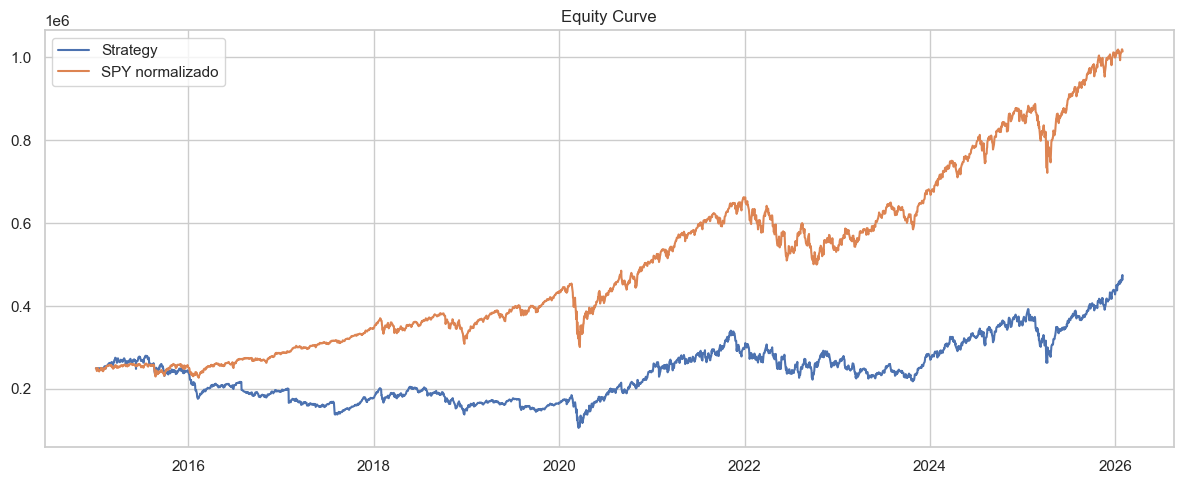

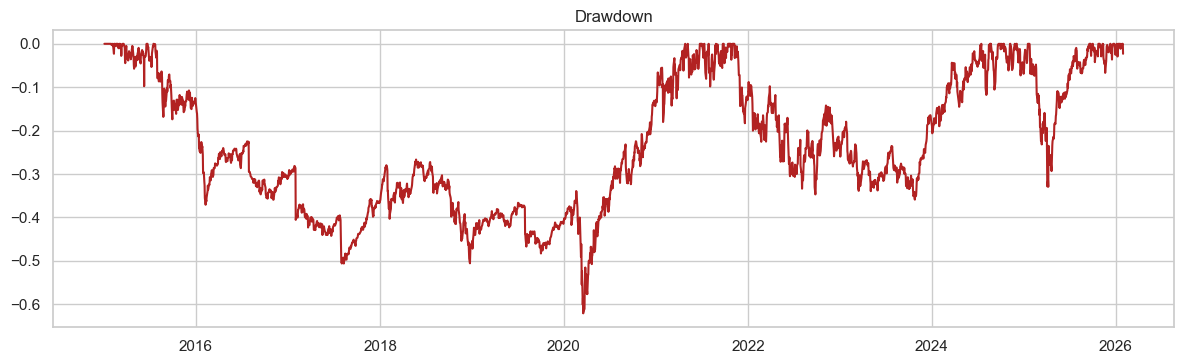

In [51]:
eq = equity_df["equity"].copy()
bench_norm = bench_close / bench_close.dropna().iloc[0] * eq.iloc[0]

plt.figure(figsize=(12, 5))
plt.plot(eq.index, eq.values, label="Strategy")
plt.plot(bench_norm.index, bench_norm.values, label="SPY normalizado")
plt.title("Equity Curve")
plt.legend()
plt.tight_layout()
plt.show()

dd = eq / eq.cummax() - 1
plt.figure(figsize=(12, 3.8))
plt.plot(dd.index, dd.values, color="firebrick")
plt.title("Drawdown")
plt.tight_layout()
plt.show()

## Analisis critico (resumen)
- La comisi?n m?nima de 23$ penaliza m?s a ?rdenes peque?as.
- Puede haber sesgo de supervivencia seg?n el universo heredado de NB1/NB2.
- El motor evita look-ahead usando solo OPEN/CLOSE de D o ?ltimo CLOSE <= D.
- No se modela slippage ni impacto de mercado (limitaci?n).

## Validacion y debug opcional (legacy)


## Resumen corto
- El flujo principal del notebook ya usa el FIX canonico de escala OPEN/CLOSE.
- El backtest oficial corre con control de coste minimo y cap diario de peso por posicion.
- La seccion de debug queda como validacion opcional para investigar desviaciones.


## Reconciliacion de retornos (motor vs datos)
